##🏡 House Price Prediction using Machine Learning

Internship: Artificial Intelligence & Machine Learning

Name: Yashi Jain

Project: House Price Prediction

#Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

#Load Dataset

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df['price'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#Dataset Shape

In [3]:
df.shape

(20640, 9)

#Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


#Check Missing Values

In [5]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


#Statistical Summary

In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#Correlation Heatmap

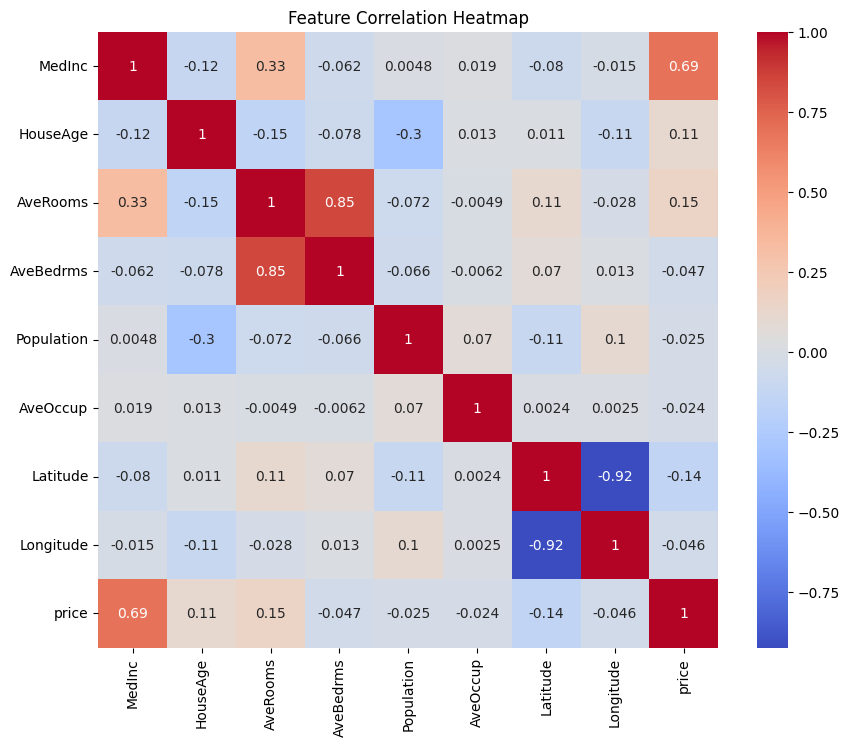

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

#Feature Distribution

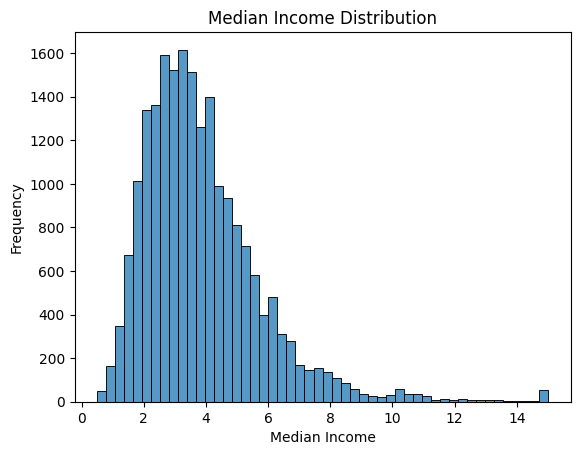

In [8]:
sns.histplot(df['MedInc'], bins=50)

plt.title("Median Income Distribution")

plt.xlabel("Median Income")

plt.ylabel("Frequency")

plt.show()

#Pairplot (Feature Relationships)

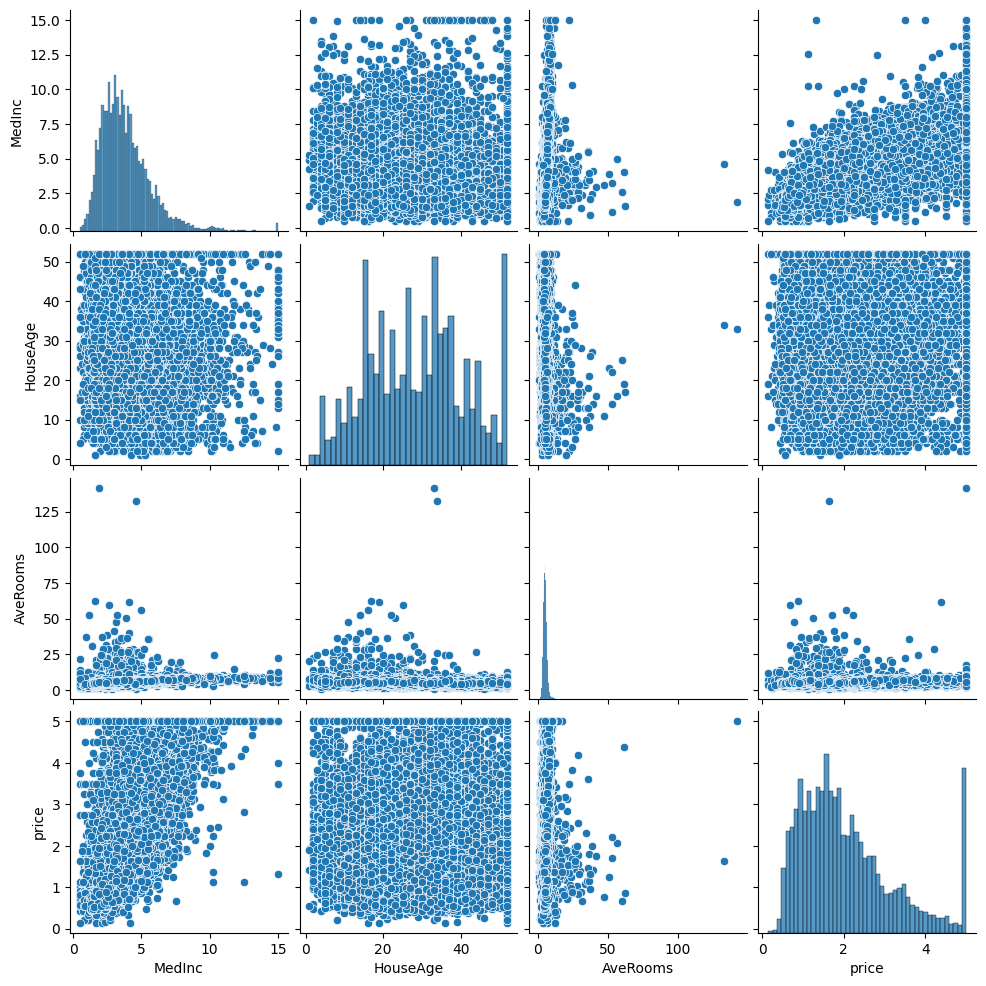

In [9]:
sns.pairplot(df[['MedInc','HouseAge','AveRooms','price']])

plt.show()

#Define Features and Target

In [10]:
X = df.drop('price', axis=1)

y = df['price']

#Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

#Train Linear Regression Model

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

#Make Predictions

In [13]:
y_pred = model.predict(X_test)

#Model Evaluation

Mean Squared Error

In [14]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.5558915986952444


R² Score

In [15]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.5757877060324508


#Actual vs Predicted Prices

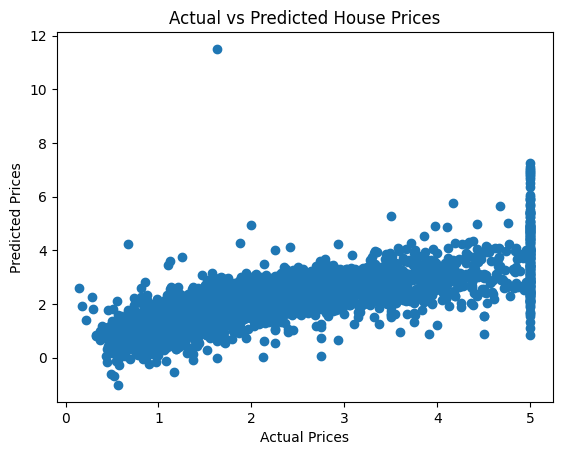

In [16]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

#Model Coefficients

In [17]:
coefficients = pd.DataFrame(

    model.coef_,
    X.columns,
    columns=['Coefficient']

)

coefficients

,Coefficient
MedInc,0.448675
HouseAge,0.009724
AveRooms,-0.123323
AveBedrms,0.783145
Population,-0.000002
AveOccup,-0.003526
Latitude,-0.419792
Longitude,-0.433708


#Example Prediction

In [18]:
sample_house = X_test.iloc[0]

prediction = model.predict([sample_house])

print("Predicted Price:", prediction[0])

Predicted Price: 0.7191228416019086


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##Conclusion

In this project, a machine learning model was developed to predict house prices based on several housing features. The California Housing dataset was analyzed using exploratory data analysis techniques and visualizations. A Linear Regression model was trained and evaluated using Mean Squared Error and R² score. The results demonstrate that machine learning regression models can effectively predict housing prices based on relevant features.